In [1]:
!pip install xgboost -q

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from sklearn.decomposition import PCA

In [4]:
# Load Dataset
country_df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
dictionary_df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv')

print("Country Dataset Shape:", country_df.shape)
country_df.head()

Country Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
country_df.info()
country_df.describe()
# Check missing values
country_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

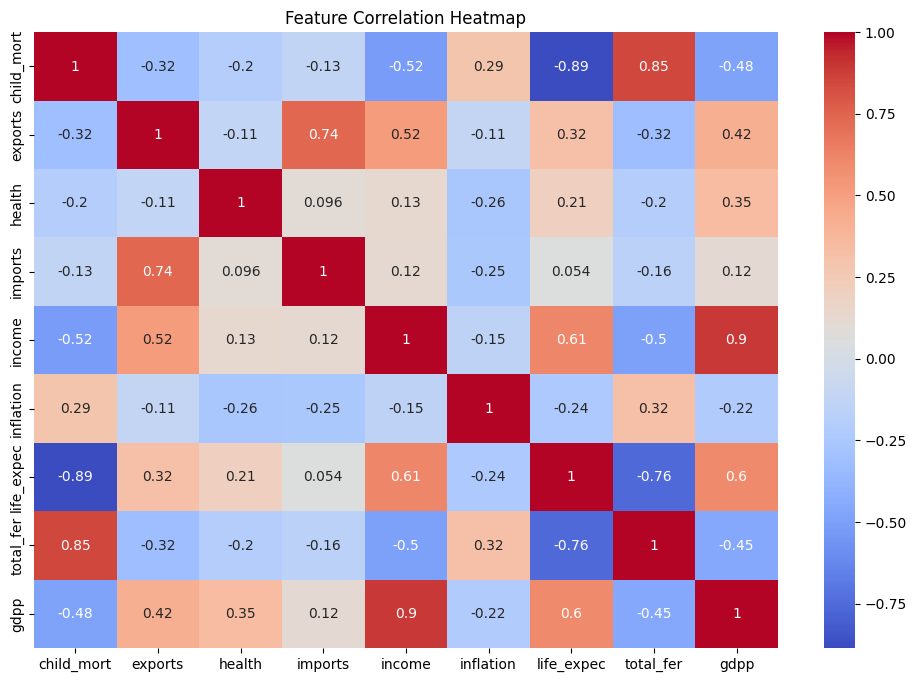

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(country_df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

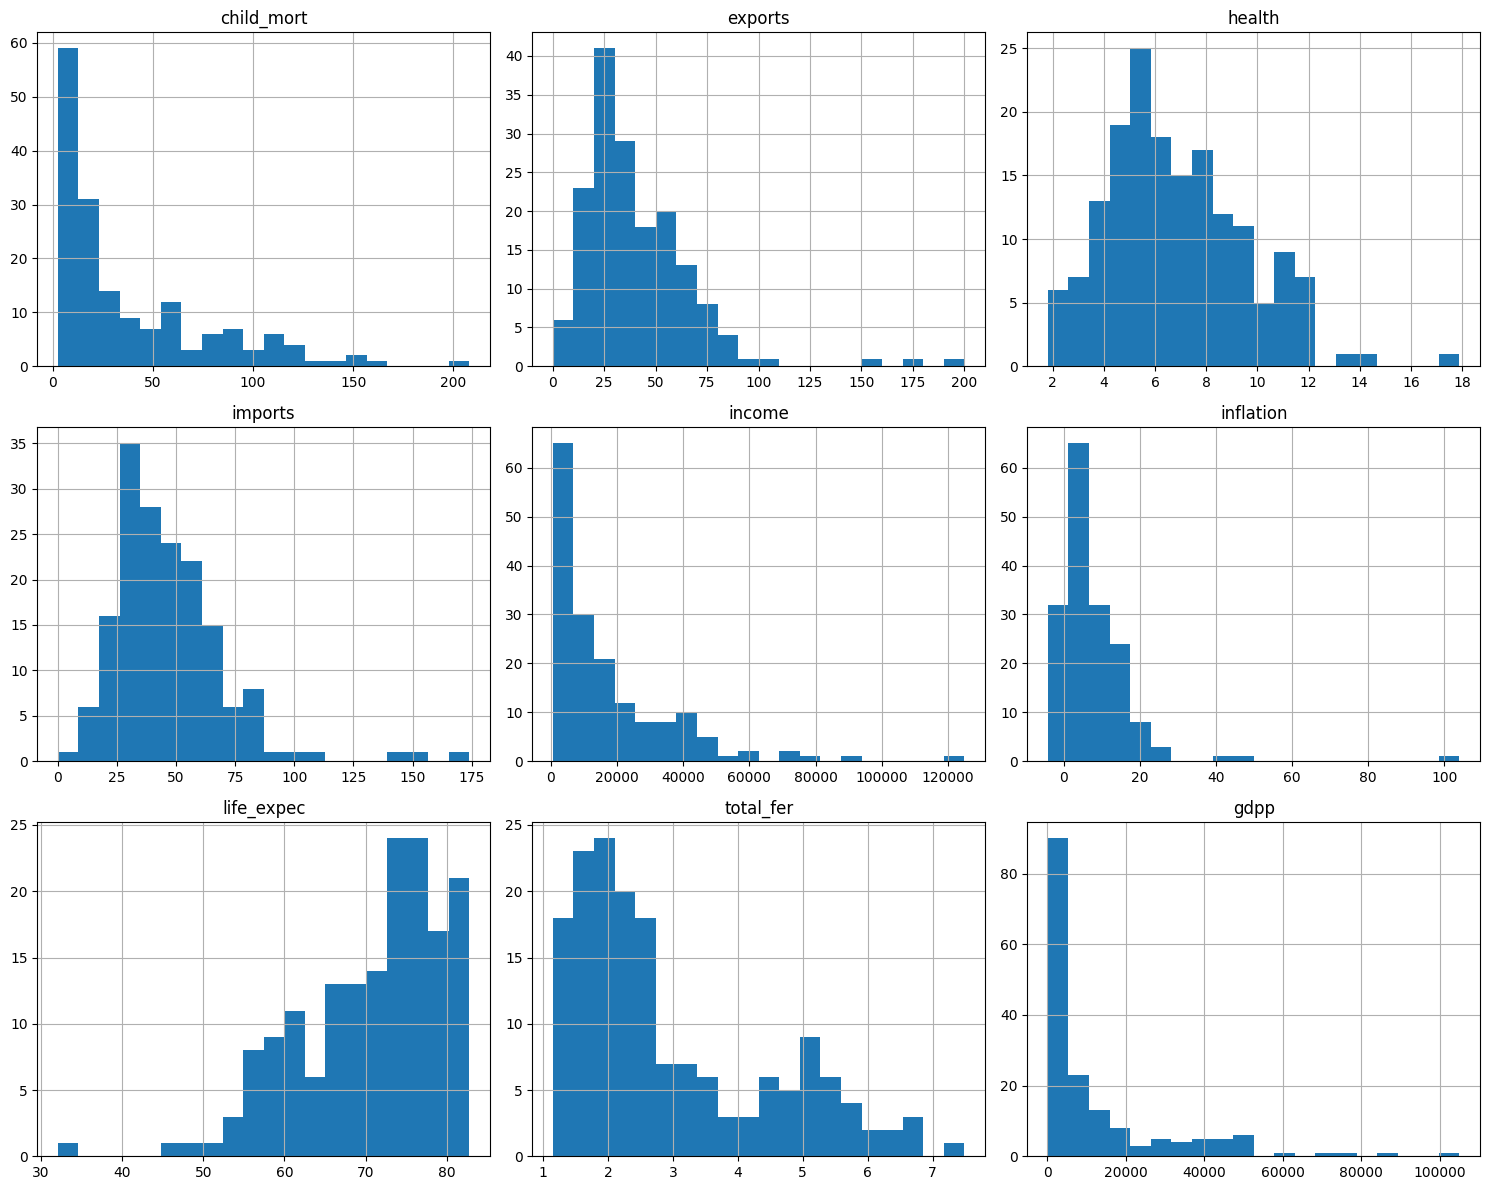

In [10]:
# Distribution of Features
country_df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

In [12]:
median_gdpp = country_df['gdpp'].median()
country_df['target'] = np.where(country_df['gdpp'] >= median_gdpp, 1, 0)
country_df[['country', 'gdpp', 'target']].head()

,country,gdpp,target
0,Afghanistan,553,0
1,Albania,4090,0
2,Algeria,4460,0
3,Angola,3530,0
4,Antigua and Barbuda,12200,1


In [16]:
X = country_df.drop(['country', 'target'], axis=1)
y = country_df['target']

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



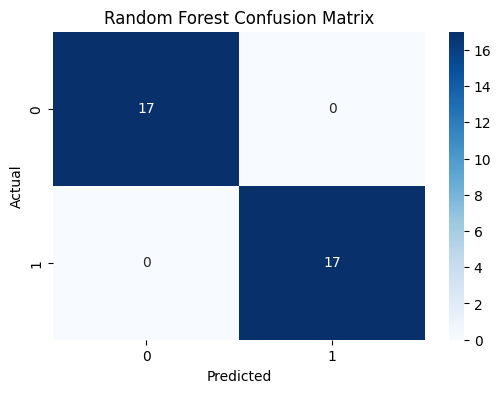

In [25]:
# Random Forest Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

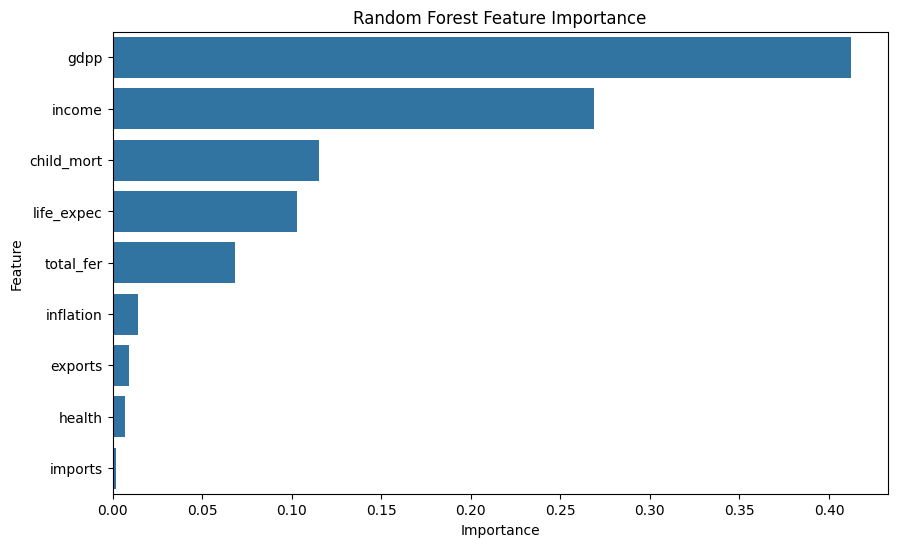

In [27]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.show()

In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



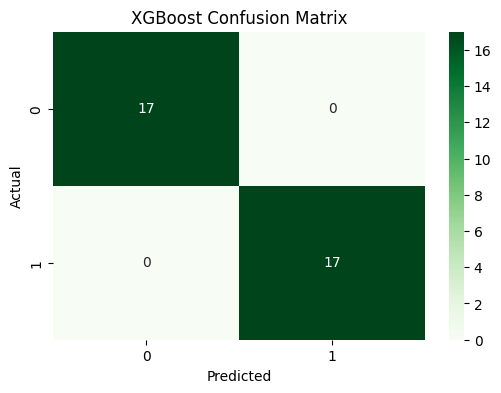

In [30]:
# XGBoost Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_acc, xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


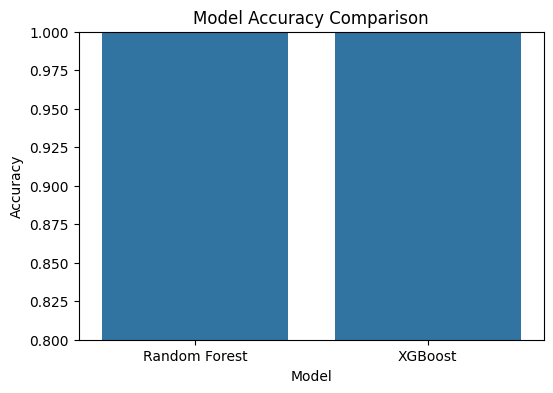

In [34]:
# Accuracy Comparison Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title('Model Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.show()

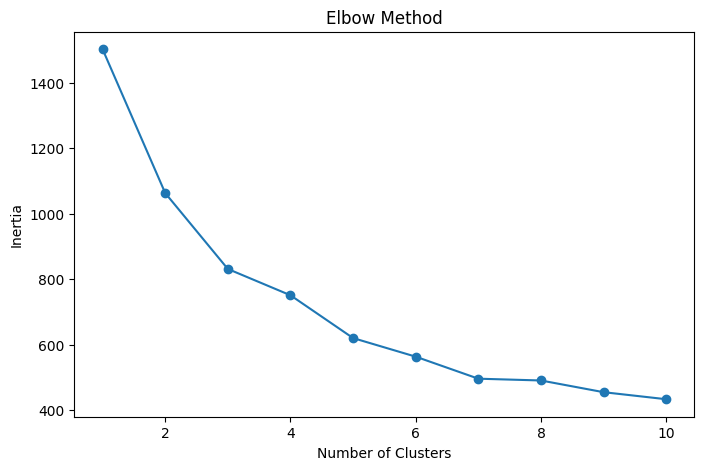

In [36]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [38]:
# K-Means Model Training
kmeans = KMeans(n_clusters=3, random_state=42)

country_df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [39]:
# K-Means Evaluation
kmeans_score = silhouette_score(X_scaled, country_df['KMeans_Cluster'])

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.285600988953231


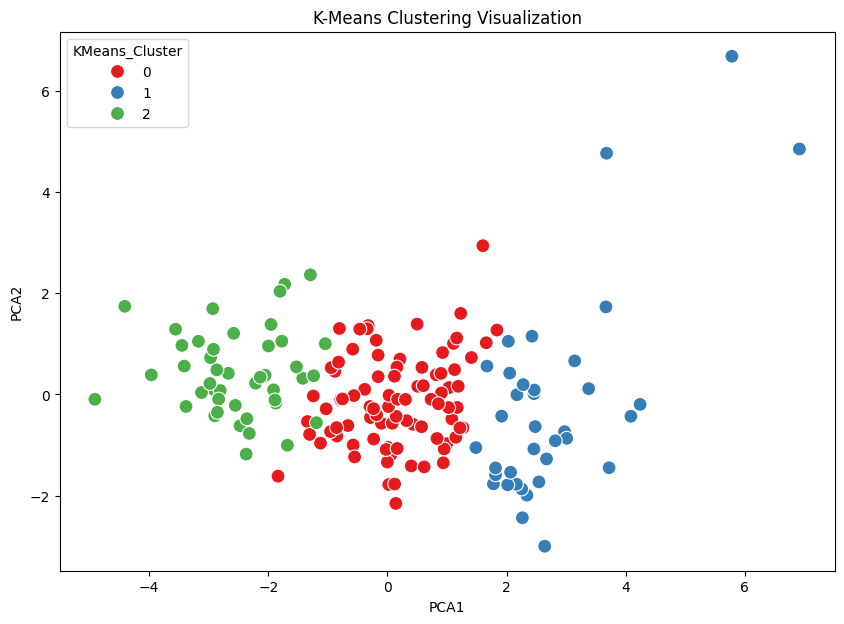

In [40]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

country_df['PCA1'] = pca_components[:,0]
country_df['PCA2'] = pca_components[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='KMeans_Cluster',
    palette='Set1',
    data=country_df,
    s=100
)

plt.title('K-Means Clustering Visualization')
plt.show()

In [41]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

country_df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

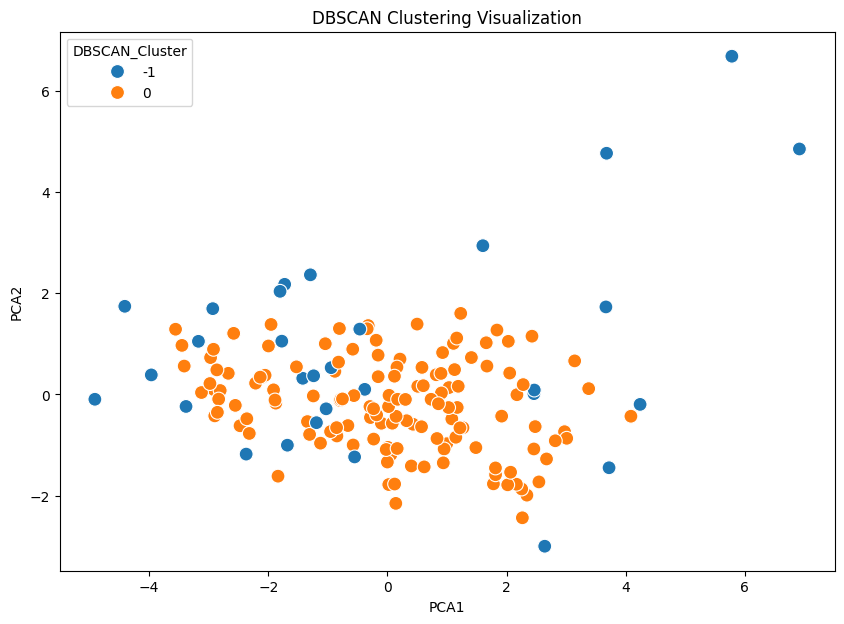

In [42]:
# Visualizing DBSCAN Clusters
plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='DBSCAN_Cluster',
    palette='tab10',
    data=country_df,
    s=100
)

plt.title('DBSCAN Clustering Visualization')
plt.show()

In [43]:
# Analyze Segments
cluster_analysis = country_df.groupby('KMeans_Cluster').mean(numeric_only=True)

cluster_analysis

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,target,PCA1,PCA2,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,0.511628,0.148884,-0.133574,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,1.000000,2.769773,-0.213014,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,0.088889,-2.500352,0.425686,-0.333333


In [45]:
for cluster in sorted(country_df['KMeans_Cluster'].unique()):
    print(f"\nCluster {cluster} Summary")
    print(country_df[country_df['KMeans_Cluster']==cluster][['country','income','gdpp','life_expec']].head())


Cluster 0 Summary
               country  income   gdpp  life_expec
1              Albania    9930   4090        76.3
2              Algeria   12900   4460        76.5
4  Antigua and Barbuda   19100  12200        76.8
5            Argentina   18700  10300        75.8
6              Armenia    6700   3220        73.3

Cluster 1 Summary
      country  income   gdpp  life_expec
7   Australia   41400  51900        82.0
8     Austria   43200  46900        80.5
11    Bahrain   41100  20700        76.0
15    Belgium   41100  44400        80.0
23     Brunei   80600  35300        77.1

Cluster 2 Summary
         country  income  gdpp  life_expec
0    Afghanistan    1610   553        56.2
3         Angola    5900  3530        60.1
17         Benin    1820   758        61.8
25  Burkina Faso    1430   575        57.9
26       Burundi     764   231        57.7


In [46]:
print("FINAL CLUSTER INSIGHTS")
print("-" * 50)

# Average values by cluster
cluster_summary = country_df.groupby('KMeans_Cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()

print(cluster_summary)

print("\nObservations:\n")

# 1
print("1. Cluster with highest child mortality:")
high_child_cluster = cluster_summary['child_mort'].idxmax()
print(f"   Cluster {high_child_cluster} has the highest child mortality rate.")
print("   These countries likely suffer from poor healthcare and low living standards.\n")

# 2
print("2. Cluster with highest income and GDP per capita:")
high_income_cluster = cluster_summary['income'].idxmax()
print(f"   Cluster {high_income_cluster} has the highest income and gdpp.")
print("   These countries are economically developed with better infrastructure.\n")

# 3
print("3. Underdeveloped cluster:")
underdeveloped_cluster = cluster_summary['gdpp'].idxmin()
print(f"   Cluster {underdeveloped_cluster} appears most underdeveloped.")
print("   It has low GDP, low income, and lower life expectancy.\n")

# 4
print("4. Countries that should be prioritized for aid:")

aid_countries = country_df[country_df['KMeans_Cluster'] == underdeveloped_cluster][['country', 'child_mort', 'income', 'gdpp']]

print(aid_countries.head(10))

print("\nThese countries require international aid and developmental support")
print("because of high child mortality and low economic conditions.\n")

# 5
print("5. DBSCAN Insight:")
print("   Countries labeled as -1 in DBSCAN are considered outliers.")
print("   These countries may have unusual economic or social indicators.")

FINAL CLUSTER INSIGHTS
--------------------------------------------------
                child_mort        income          gdpp  life_expec
KMeans_Cluster                                                    
0                22.456977  12321.744186   6461.767442   72.566279
1                 5.000000  45672.222222  42494.444444   80.127778
2                95.106667   3539.844444   1766.711111   59.055556

Observations:

1. Cluster with highest child mortality:
   Cluster 2 has the highest child mortality rate.
   These countries likely suffer from poor healthcare and low living standards.

2. Cluster with highest income and GDP per capita:
   Cluster 1 has the highest income and gdpp.
   These countries are economically developed with better infrastructure.

3. Underdeveloped cluster:
   Cluster 2 appears most underdeveloped.
   It has low GDP, low income, and lower life expectancy.

4. Countries that should be prioritized for aid:
                     country  child_mort  income  gdp